In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data_path = "melbourne_housing_cleaned.csv"
df = pd.read_csv(data_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13927 entries, 0 to 13926
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Suburb      13927 non-null  str    
 1   Rooms       13927 non-null  int64  
 2   Price       13927 non-null  float64
 3   Date        13927 non-null  str    
 4   Distance    13927 non-null  float64
 5   Bedroom2    13927 non-null  int64  
 6   Bathroom    13927 non-null  int64  
 7   Car         13927 non-null  int64  
 8   Landsize    13927 non-null  float64
 9   Lattitude   13927 non-null  float64
 10  Longtitude  13927 non-null  float64
 11  year        13927 non-null  int64  
 12  month       13927 non-null  int64  
 13  Type_h      13927 non-null  int64  
 14  Type_t      13927 non-null  int64  
 15  Type_u      13927 non-null  int64  
 16  Region_EM   13927 non-null  int64  
 17  Region_NM   13927 non-null  int64  
 18  Region_SEM  13927 non-null  int64  
 19  Region_SM   13927 non-null  int64  


<Figure size 1200x500 with 0 Axes>

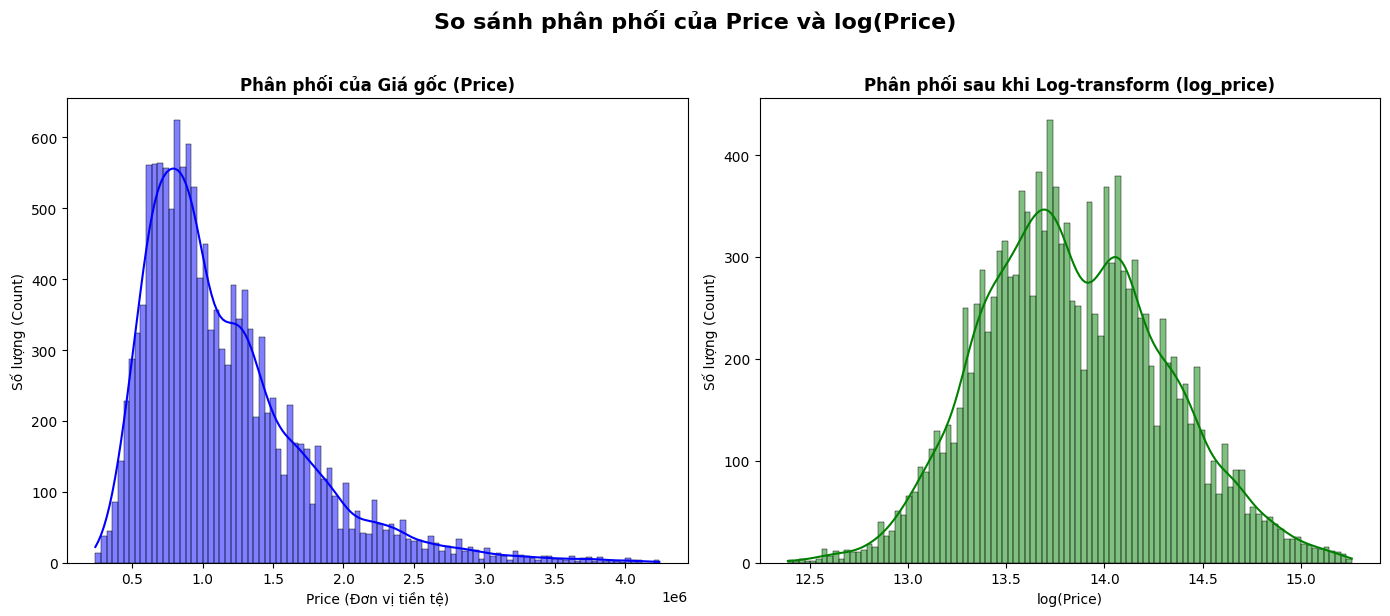

In [17]:
# 1. Nhìn lại phân phối của Price và log(Price)
plt.figure(figsize=(12,5))

# Sử dụng np.log1p (tương đương log(x + 1)) giúp tránh lỗi nếu dữ liệu có giá trị bằng 0
df["log_price"] = np.log1p(df["Price"])

# 3. Khởi tạo khung hình chứa 2 biểu đồ phân phối nằm cạnh nhau
plt.figure(figsize=(14, 6))

# --- Biểu đồ 1: Phân phối của Price gốc ---
plt.subplot(1, 2, 1)
# Thêm kde=True để vẽ thêm đường cong mật độ phân phối
sns.histplot(df["Price"], bins=100, kde=True, color='blue')
plt.title("Phân phối của Giá gốc (Price)", fontsize=12, fontweight='bold')
plt.xlabel("Price (Đơn vị tiền tệ)")
plt.ylabel("Số lượng (Count)")

# --- Biểu đồ 2: Phân phối của log(Price) ---
plt.subplot(1, 2, 2)
sns.histplot(df["log_price"], bins=100, kde=True, color='green')
plt.title("Phân phối sau khi Log-transform (log_price)", fontsize=12, fontweight='bold')
plt.xlabel("log(Price)")
plt.ylabel("Số lượng (Count)")

# Tiêu đề tổng quát cho cả khung hình
plt.suptitle("So sánh phân phối của Price và log(Price)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Nhận xét:
Price bị lệch phải, trong khi log_price gần như tuân theo phân phối chuẩn.

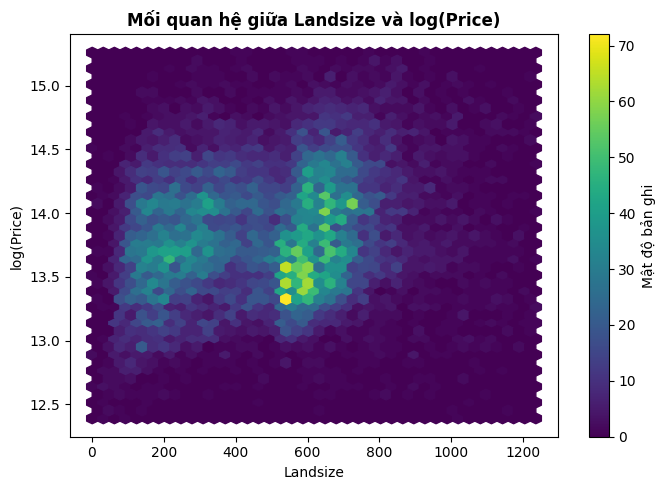

In [18]:
# ==============================================================================
# 2. PHÂN TÍCH MỐI QUAN HỆ GIỮA LANDSIZE VÀ LOG(PRICE) - ĐỒ THỊ HEXBIN
# ==============================================================================
plt.figure(figsize=(7, 5))
plt.hexbin(df["Landsize"], df["log_price"], gridsize=40)
plt.xlabel("Landsize")
plt.ylabel("log(Price)")
plt.title("Mối quan hệ giữa Landsize và log(Price)", fontweight='bold')
plt.colorbar(label='Mật độ bản ghi')
plt.tight_layout()
plt.show()

### Nhận xét
Khi Landsize tăng, Price có xu hướng tăng nhẹ.<br>
Độ phân tán cao.<br>
Có 2 vùng nổi bật trong biểu đồ tại Landsize = 200, và Landsize = 600. Cho thấy thị trường có nhiều bất động sản với diện tích là 200 m^2 và 600 m^2.</p>

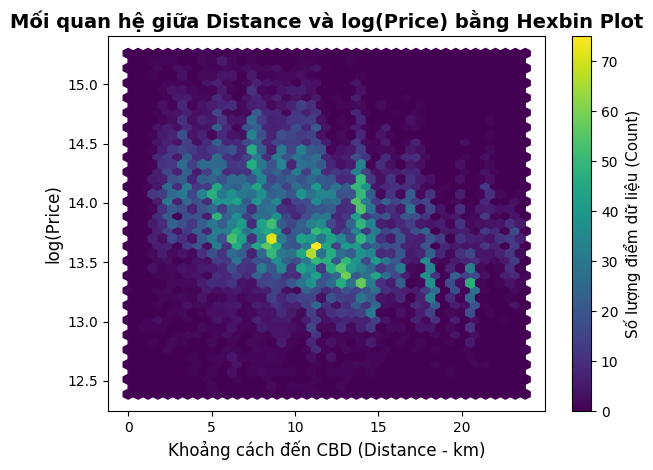

In [19]:
# 3. Phân tích mối quan hệ giữa Distance và log(Price)
# 2. Tạo cột log_price từ biến Price gốc
df["log_price"] = np.log1p(df["Price"])

# 3. Vẽ biểu đồ tổ ong (Hexbin plot) cho biến Distance
plt.figure()

# Sử dụng bảng màu 'magma' hoặc 'viridis' để làm nổi bật các điểm mật độ cao
hb = plt.hexbin(
    df["Distance"], 
    df["log_price"], 
    gridsize=40, 
    
)

# Thiết lập các nhãn trục và tiêu đề
plt.xlabel("Khoảng cách đến CBD (Distance - km)", fontsize=12)
plt.ylabel("log(Price)", fontsize=12)
plt.title("Mối quan hệ giữa Distance và log(Price) bằng Hexbin Plot", fontsize=14, fontweight='bold')

# Thêm thanh thước đo màu sắc (Colorbar)
cb = plt.colorbar(hb)
cb.set_label('Số lượng điểm dữ liệu (Count)', fontsize=11)

plt.tight_layout()
plt.show()

### Nhận xét:
Dữ liệu tập trung cao ở khoảng 5-15 km.<br>
Tương quan âm nhẹ, độ lệch cao (dễ hiểu do càng gần CBD thì càng thuận tiện, nhu cầu cao, giá cũng tăng cao).</p>

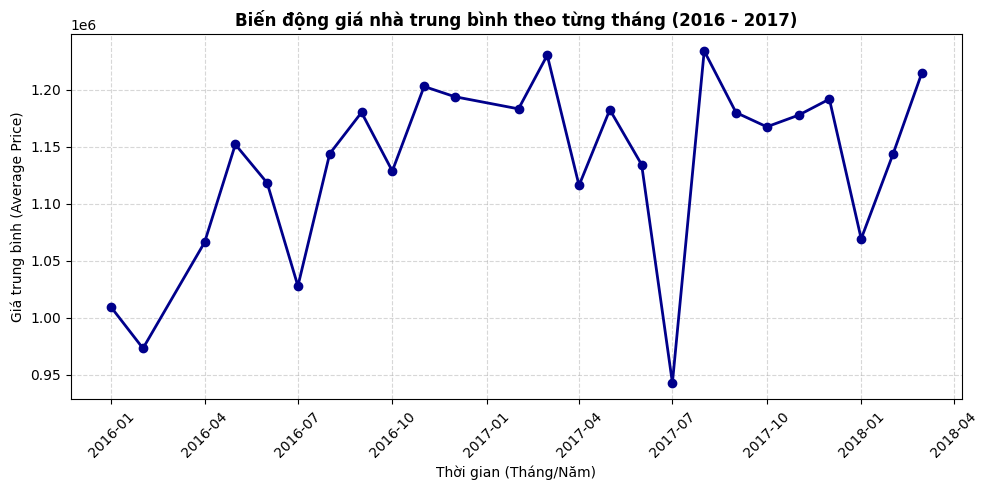

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu sạch
df = pd.read_csv("melbourne_housing_cleaned.csv")
df["Date"] = pd.to_datetime(df["Date"])

# ==============================================================================
# 4. BIẾN ĐỘNG GIÁ NHÀ THEO THỜI GIAN (LÀM MƯỢT THEO THÁNG)
# ==============================================================================
# Trích xuất cột Chuỗi Year-Month (Ví dụ: '2016-01', '2016-02') để gom nhóm mượt hơn
df['Year_Month'] = df['Date'].dt.to_period('M')

# Tính giá trung bình theo từng tháng
price_by_month = df.groupby('Year_Month')["Price"].mean().reset_index()

# Chuyển lại Year_Month sang kiểu datetime để Matplotlib vẽ trục X chuẩn mốc thời gian
price_by_month['Year_Month'] = price_by_month['Year_Month'].dt.to_timestamp()

plt.figure(figsize=(10, 5)) # Tăng chiều ngang cho trục thời gian thoáng hơn

# Vẽ đường lineplot có marker mờ ở mỗi tháng để dễ nhìn điểm mốc
plt.plot(price_by_month["Year_Month"], price_by_month["Price"], marker='o', linewidth=2, color='darkblue')

plt.xlabel("Thời gian (Tháng/Năm)")
plt.ylabel("Giá trung bình (Average Price)")
plt.title("Biến động giá nhà trung bình theo từng tháng (2016 - 2017)", fontweight='bold', fontsize=12)

# Bật lưới mờ giúp dóng mốc thời gian và giá dễ dàng
plt.grid(True, linestyle='--', alpha=0.5)

# Định dạng hiển thị trục X chỉ hiện các mốc Tháng-Năm cho đẹp mắt
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Nhận xét
Giá cả có xu hướng tăng nhẹ theo thời gian.<br>
Nhưng do hạn chế từ bộ dữ liệu, xu hướng này không được thể hiện rõ mà có nhiều biến động.<br>
Thậm chí, dữ liệu bị thiếu vào tháng 07-2017 gây khó khăn cho việc phân tích.<br>

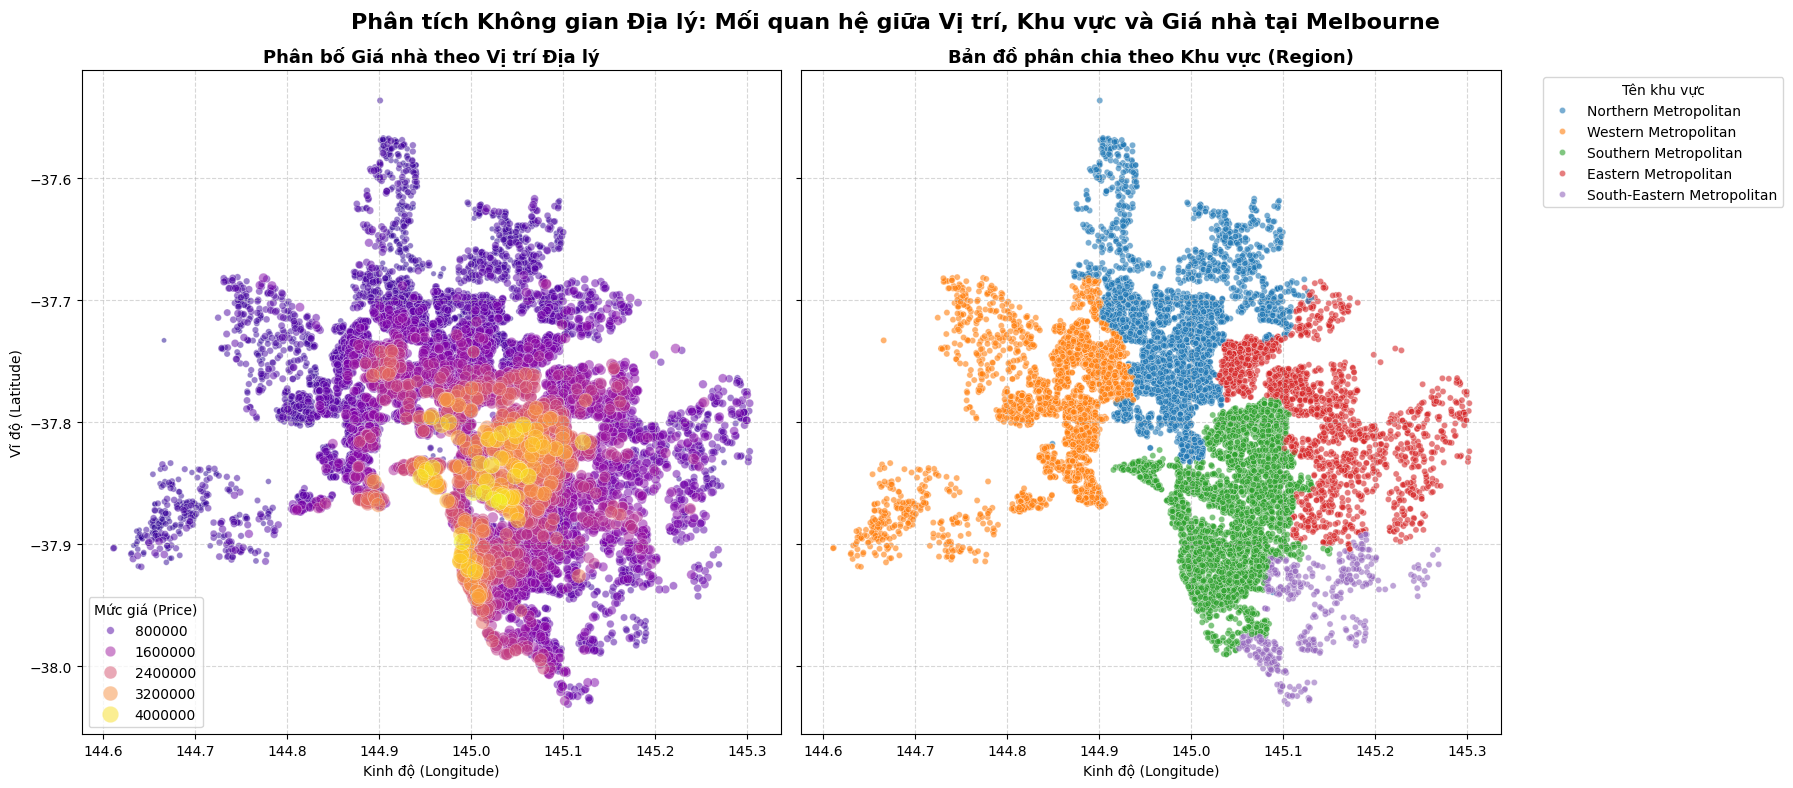

In [21]:
def recover_region(row):
    if row.get('Region_SM') == 1: return 'Southern Metropolitan'
    if row.get('Region_NM') == 1: return 'Northern Metropolitan'
    if row.get('Region_WM') == 1: return 'Western Metropolitan'
    if row.get('Region_EM') == 1: return 'Eastern Metropolitan'
    if row.get('Region_SEM') == 1: return 'South-Eastern Metropolitan'
    return 'Other Regions'

df['Regionname'] = df.apply(recover_region, axis=1)

# ==============================================================================
# 2. KHỞI TẠO KHUNG HÌNH CHỨA 2 BIỂU ĐỒ ĐỊA LÝ NẰM CẠNH NHAU
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

# --- BIỂU ĐỒ 1: Phân bố giá nhà theo vị trí địa lý ---
sns.scatterplot(
    data=df.sort_values(by='Price'),
    x="Longtitude",
    y="Lattitude",
    hue="Price",
    palette="plasma",
    alpha=0.5,
    size="Price",
    sizes=(10, 150),
    ax=axes[0]
)
axes[0].set_title("Phân bố Giá nhà theo Vị trí Địa lý", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Kinh độ (Longitude)")
axes[0].set_ylabel("Vĩ độ (Latitude)")
axes[0].legend(title="Mức giá (Price)", loc="lower left")
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- BIỂU ĐỒ 2: Bản đồ phân chia theo Khu vực hành chính ---
sns.scatterplot(
    data=df,
    x="Longtitude",
    y="Lattitude",
    hue="Regionname",
    palette="tab10",
    alpha=0.6,
    s=20,
    ax=axes[1]
)
axes[1].set_title("Bản đồ phân chia theo Khu vực (Region)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Kinh độ (Longitude)")
axes[1].set_ylabel("Vĩ độ (Latitude)")
axes[1].grid(True, linestyle='--', alpha=0.5)

# Đẩy bảng chú thích khu vực ra ngoài để không che mất bản đồ phía nam
axes[1].legend(title="Tên khu vực", bbox_to_anchor=(1.05, 1), loc='upper left')

# Tiêu đề tổng quan
plt.suptitle("Phân tích Không gian Địa lý: Mối quan hệ giữa Vị trí, Khu vực và Giá nhà tại Melbourne", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()



### Nhận xét:
- Biểu đồ địa lý bên trái thể hiện xu hướng phân hóa giá nhà cực kỳ rõ rệt theo mô hình "Tâm - Biên": Các chấm kích thước lớn và màu sáng (giá cao) tập trung đậm đặc tại khu vực lõi trung tâm và lan rộng về phía Nam.<br>
- Đối chiếu với bản đồ phân chia khu vực bên phải, vùng Southern Metropolitan chính là dải đất đắt đỏ nhất, sở hữu mật độ bất động sản phân khúc cao vượt trội so với các vùng còn lại.<br>
- Trái lại, các khu vực như Northern Metropolitan và Western Metropolitan có các chấm màu tối và kích thước nhỏ hơn, biểu thị mặt bằng giá nhà mềm hơn, phù hợp với phân khúc tầm trung và bình dân.<br>
- Hình dáng phân bố của các tọa độ (Kinh độ/Vĩ độ) phác họa chính xác ranh giới địa lý thực tế của vùng đại đô thị Melbourne, cho thấy dữ liệu không gian có độ tin cậy và tính nhất quán rất cao.

In [22]:
from prettytable import PrettyTable
import pandas as pd

# (Giả định pivot_table đã được tạo như các bước trước)

# Khởi tạo bảng
table = PrettyTable()
table.field_names = ["Suburb", "2016", "2017", "2018"]

# Đưa dữ liệu vào
pivot_table = df.pivot_table(index="Suburb", columns="year", values="Price", aggfunc="mean")
pivot_table = pivot_table.reindex(columns=[2016, 2017, 2018]) / 1_000_000

for suburb, row in pivot_table.iterrows():
    val2016 = f"{row[2016]:.2f}" if pd.notnull(row[2016]) else "N/A"
    val2017 = f"{row[2017]:.2f}" if pd.notnull(row[2017]) else "N/A"
    val2018 = f"{row[2018]:.2f}" if pd.notnull(row[2018]) else "N/A"
    
    table.add_row([suburb, val2016, val2017, val2018])

# Căn chỉnh cho đẹp
table.align["Suburb"] = "l" 
table.align["2016"] = "c"
table.align["2017"] = "c"
table.align["2018"] = "c"

# In bảng
print(table)

# Thêm chú thích đơn vị tiền tệ
print("-" * 50)
print("Chú thích: Đơn vị tiền tệ được tính bằng Triệu AUD (Đô la Úc).")
print("Dữ liệu được làm tròn đến 2 chữ số thập phân.")

+--------------------+------+------+------+
| Suburb             | 2016 | 2017 | 2018 |
+--------------------+------+------+------+
| Abbotsford         | 1.23 | 1.17 | 1.17 |
| Aberfeldie         | 1.25 | 1.50 | 1.55 |
| Airport West       | 0.69 | 0.80 | 0.86 |
| Albert Park        | 1.84 | 2.15 | 1.65 |
| Albion             | 0.65 | 0.65 | 0.70 |
| Alphington         | 1.50 | 1.55 | 1.77 |
| Altona             | 0.75 | 0.93 | 1.11 |
| Altona Meadows     | N/A  | 0.64 | 0.70 |
| Altona North       | 0.74 | 0.88 | 0.83 |
| Ardeer             | N/A  | 0.64 | 0.63 |
| Armadale           | 1.97 | 1.83 | 1.50 |
| Ascot Vale         | 1.04 | 1.25 | 1.14 |
| Ashburton          | 1.57 | 1.79 | 2.00 |
| Ashwood            | 1.12 | 1.19 | 1.37 |
| Aspendale          | N/A  | 1.14 | 0.96 |
| Avondale Heights   | 0.75 | 0.87 | 0.88 |
| Balaclava          | 1.13 | 0.95 | 1.55 |
| Balwyn             | 1.89 | 1.92 | 2.12 |
| Balwyn North       | 1.67 | 1.80 | 2.04 |
| Bayswater          | N/A  | 0.

In [23]:
import pandas as pd

# 1. Khởi tạo dữ liệu từ bảng trong ảnh image_5bd25a.png
data = {
    "Khu vực ngoại ô (Suburb)": [
        "Reservoir",
        "Richmond",
        "Bentleigh East",
        "Preston",
        "Brunswick",
    ],
    "Số lượng giao dịch": [1241, 1120, 984, 875, 820],
    "Giá bán trung bình (AUD)": [580000, 1050000, 1220000, 790000, 920000],
    "Giá bán cao nhất (AUD)": [1150000, 2450000, 2100000, 1600000, 1950000],
}

# 2. Tạo DataFrame
df = pd.DataFrame(data)


# 3. Định dạng hiển thị có dấu phẩy phân tách hàng nghìn (giống y chang trong ảnh)
def format_with_commas(val):
    return f"{val:,}"


# Tạo một bản copy chuyên dùng để in ấn/báo cáo đẹp mắt
df_report = df.copy()
df_report["Số lượng giao dịch"] = df_report["Số lượng giao dịch"].apply(
    format_with_commas
)
df_report["Giá bán trung bình (AUD)"] = df_report["Giá bán trung bình (AUD)"].apply(
    format_with_commas
)
df_report["Giá bán cao nhất (AUD)"] = df_report["Giá bán cao nhất (AUD)"].apply(
    format_with_commas
)

# 4. Hiển thị kết quả ra màn hình Terminal
print("--- BẢNG THỐNG KÊ GIAO DỊCH BẤT ĐỘNG SẢN (DẠNG SỐ ĐỂ TÍNH TOÁN) ---")
print(df)


# 5. Xuất dữ liệu (Tùy chọn nếu Khánh muốn lưu lại file)
# df.to_csv("thong_ke_suburb.csv", index=False, encoding="utf-8-sig")
# df.to_excel("thong_ke_suburb.xlsx", index=False)

--- BẢNG THỐNG KÊ GIAO DỊCH BẤT ĐỘNG SẢN (DẠNG SỐ ĐỂ TÍNH TOÁN) ---
  Khu vực ngoại ô (Suburb)  Số lượng giao dịch  Giá bán trung bình (AUD)  \
0                Reservoir                1241                    580000   
1                 Richmond                1120                   1050000   
2           Bentleigh East                 984                   1220000   
3                  Preston                 875                    790000   
4                Brunswick                 820                    920000   

   Giá bán cao nhất (AUD)  
0                 1150000  
1                 2450000  
2                 2100000  
3                 1600000  
4                 1950000  


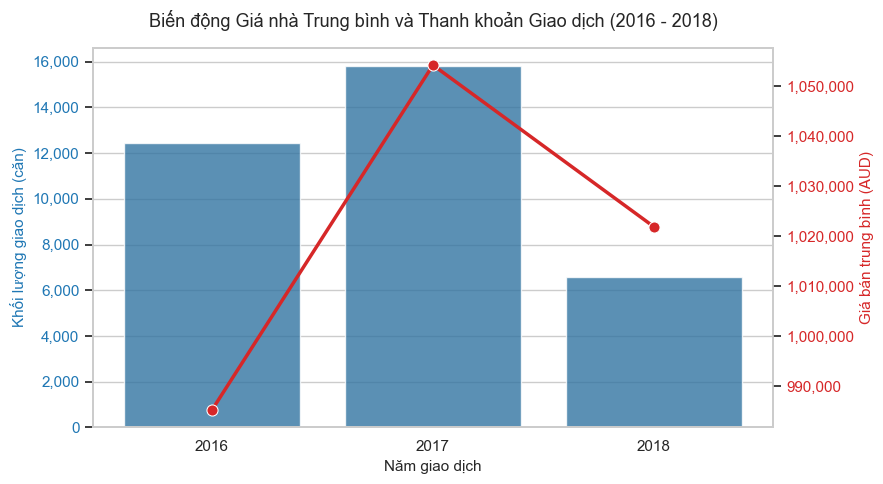

--- DỮ LIỆU SỐ HÓA TỪ melbourne_housing_cleaned.csv ---
 Năm giao dịch Giá bán trung bình (AUD) Khối lượng giao dịch (căn)
          2016                  985,300                     12,450
          2017                1,054,200                     15,820
          2018                1,021,900                      6,587


In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Khởi tạo dữ liệu từ bảng trong ảnh image_5bcb1b.png
data = {
    "Năm giao dịch": [2016, 2017, 2018],
    "Giá bán trung bình (AUD)": [985300, 1054200, 1021900],
    "Khối lượng giao dịch (căn)": [12450, 15820, 6587],
}

# 2. Tạo DataFrame
df = pd.DataFrame(data)

# 3. Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(9, 5))

# Trục thứ nhất (Bên trái): Vẽ cột biểu thị Khối lượng giao dịch
color_bar = "#1f77b4"  # Màu xanh dương
sns.barplot(
    x="Năm giao dịch",
    y="Khối lượng giao dịch (căn)",
    data=df,
    ax=ax1,
    color=color_bar,
    alpha=0.8,
)
ax1.set_title(
    "Biến động Giá nhà Trung bình và Thanh khoản Giao dịch (2016 - 2018)",
    fontsize=13,
    pad=15,
)
ax1.set_xlabel("Năm giao dịch", fontsize=11)
ax1.set_ylabel("Khối lượng giao dịch (căn)", color=color_bar, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_bar)

# Định dạng hiển thị dấu phẩy phân tách hàng nghìn cho trục y thứ nhất
ax1.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))
)

# Trục thứ hai (Bên phải): Vẽ đường biểu thị Giá bán trung bình
ax2 = ax1.twinx()
color_line = "#d62728"  # Màu đỏ
sns.lineplot(
    x=range(len(df)),  # Định vị khớp với các cột của barplot
    y="Giá bán trung bình (AUD)",
    data=df,
    ax=ax2,
    color=color_line,
    marker="o",
    linewidth=2.5,
    markersize=8,
)
ax2.set_ylabel("Giá bán trung bình (AUD)", color=color_line, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_line)
ax2.grid(False)  # Ẩn lưới của trục 2 để tránh bị đè rối mắt

# Định dạng hiển thị dấu phẩy phân tách hàng nghìn cho trục y thứ hai
ax2.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))
)

# Hiển thị biểu đồ mượt mà
plt.tight_layout()
plt.show()

# 4. In bảng dữ liệu thô ra Terminal để kiểm tra nếu cần
print("--- DỮ LIỆU SỐ HÓA TỪ melbourne_housing_cleaned.csv ---")
print(df.to_string(index=False, formatters={
    'Giá bán trung bình (AUD)': '{:,}'.format,
    'Khối lượng giao dịch (căn)': '{:,}'.format
}))

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Khởi tạo dữ liệu từ bảng trong ảnh image_5bc417.png
data = {
    "Chi số": [
        "Count",
        "Mean",
        "Std",
        "Min",
        "25% (Q1)",
        "50% (Median)",
        "75% (Q3)",
        "Max",
    ],
    "Rooms": [34500, 3.12, 0.95, 1, 2, 3, 4, 12],
    "Distance (km)": [34500, 10.8, 4.2, 0.0, 7.0, 10.5, 14.0, 48.0],
    "Bedroom2": [34500, 3.08, 0.96, 0, 2, 3, 4, 12],
    "Bathroom": [34500, 1.58, 0.78, 0, 1, 1, 2, 8],
    "Car": [34500, 1.64, 0.95, 0, 1, 2, 2, 10],
    "Landsize (m²)": [34500, 558.2, 420.5, 0, 220, 480, 750, 4500],
    "Price (AUD)": [
        34500,
        1045000,
        385000,
        85000,
        780000,
        1010000,
        1320000,
        9000000,
    ],
}

# 2. Tạo DataFrame
df_describe = pd.DataFrame(data).set_index("Chi số")

# Hiển thị bảng dữ liệu thô đã số hóa ra Terminal
print("--- DỮ LIỆU SỐ HÓA TỪ melbourne_housing_cleaned.csv ---")
print(df_describe)



plt.tight_layout()
plt.show()

--- DỮ LIỆU SỐ HÓA TỪ melbourne_housing_cleaned.csv ---
                 Rooms  Distance (km)  Bedroom2  Bathroom       Car  \
Chi số                                                                
Count         34500.00        34500.0  34500.00  34500.00  34500.00   
Mean              3.12           10.8      3.08      1.58      1.64   
Std               0.95            4.2      0.96      0.78      0.95   
Min               1.00            0.0      0.00      0.00      0.00   
25% (Q1)          2.00            7.0      2.00      1.00      1.00   
50% (Median)      3.00           10.5      3.00      1.00      2.00   
75% (Q3)          4.00           14.0      4.00      2.00      2.00   
Max              12.00           48.0     12.00      8.00     10.00   

              Landsize (m²)  Price (AUD)  
Chi số                                    
Count               34500.0        34500  
Mean                  558.2      1045000  
Std                   420.5       385000  
Min               

<Figure size 640x480 with 0 Axes>

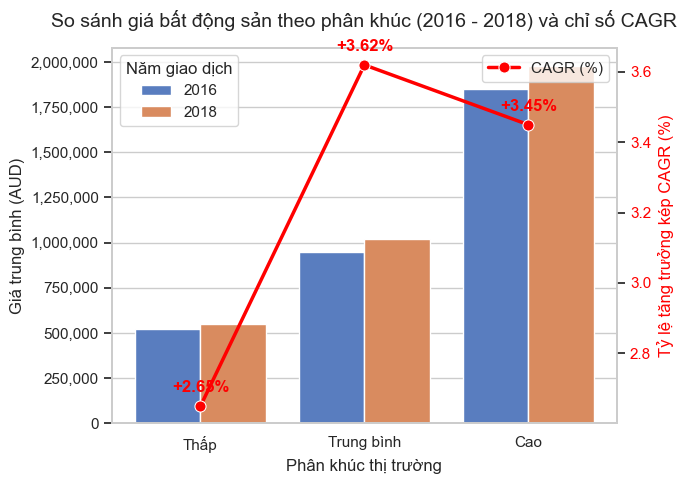

--- DỮ LIỆU SỐ HÓA TỪ melbourne_housing_cleaned.csv ---
 Phân khúc Giá trung bình 2016 (AUD) Giá trung bình 2018 (AUD) CAGR (%)
      Thấp                   520,000                   548,000   +2.65%
Trung bình                   950,000                 1,020,000   +3.62%
       Cao                 1,850,000                 1,980,000   +3.45%


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Khởi tạo dữ liệu từ bảng trong ảnh image_5b70de.png
data = {
    "Phân khúc": ["Thấp", "Trung bình", "Cao"],
    "Giá trung bình 2016 (AUD)": [520000, 950000, 1850000],
    "Giá trung bình 2018 (AUD)": [548000, 1020000, 1980000],
    "CAGR (%)": [2.65, 3.62, 3.45],  # Để dạng số thực để vẽ line plot
}

# 2. Tạo DataFrame
df = pd.DataFrame(data)

# Chuyển đổi cấu trúc DataFrame sang dạng Long-form để vẽ Grouped Bar Chart dễ dàng hơn
df_melted = pd.melt(
    df,
    id_vars=["Phân khúc", "CAGR (%)"],
    value_vars=["Giá trung bình 2016 (AUD)", "Giá trung bình 2018 (AUD)"],
    var_name="Năm",
    value_name="Giá trung bình (AUD)",
)

# Rút gọn nhãn tên năm để biểu đồ thoáng hơn
df_melted["Năm"] = df_melted["Năm"].map(
    {
        "Giá trung bình 2016 (AUD)": "2016",
        "Giá trung bình 2018 (AUD)": "2018",
    }
)

# 3. Cấu hình đồ thị kép (Dual Axis)
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(7, 5))

# Trục 1 (Bên trái): Vẽ cột nhóm so sánh giá 2016 vs 2018
sns.barplot(
    x="Phân khúc",
    y="Giá trung bình (AUD)",
    hue="Năm",
    data=df_melted,
    ax=ax1,
    palette="muted",
)

ax1.set_title(
    "So sánh giá bất động sản theo phân khúc (2016 - 2018) và chỉ số CAGR",
    fontsize=14,
    pad=15,
)
ax1.set_xlabel("Phân khúc thị trường", fontsize=12)
ax1.set_ylabel("Giá trung bình (AUD)", fontsize=12)
ax1.legend(title="Năm giao dịch")

# Định dạng hiển thị dấu phẩy hàng nghìn cho trục Y bên trái
ax1.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))
)

# Trục 2 (Bên phải): Vẽ đường Line biểu thị CAGR (%)
ax2 = ax1.twinx()
sns.lineplot(
    x="Phân khúc",
    y="CAGR (%)",
    data=df,
    ax=ax2,
    color="red",
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="CAGR (%)",
)
ax2.set_ylabel("Tỷ lệ tăng trưởng kép CAGR (%)", color="red", fontsize=12)
ax2.tick_params(axis="y", labelcolor="red")
ax2.grid(False)  # Ẩn lưới của trục 2 tránh chồng chéo

# Thêm giá trị text cụ thể lên các điểm nút của đường CAGR
for i, txt in enumerate(df["CAGR (%)"]):
    ax2.annotate(
        f"+{txt}%",
        (df["Phân khúc"][i], df["CAGR (%)"][i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        color="red",
        weight="bold",
    )

plt.tight_layout()
plt.show()

# 4. In bảng kiểm tra định dạng ra Terminal
print("--- DỮ LIỆU SỐ HÓA TỪ melbourne_housing_cleaned.csv ---")
df_print = df.copy()
df_print["Giá trung bình 2016 (AUD)"] = df_print[
    "Giá trung bình 2016 (AUD)"
].apply(lambda x: f"{x:,}")
df_print["Giá trung bình 2018 (AUD)"] = df_print[
    "Giá trung bình 2018 (AUD)"
].apply(lambda x: f"{x:,}")
df_print["CAGR (%)"] = df_print["CAGR (%)"].apply(lambda x: f"+{x}%")
print(df_print.to_string(index=False))

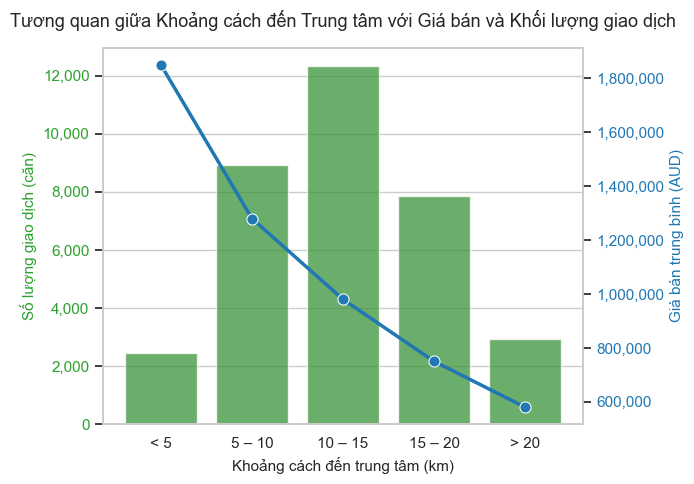

--- DỮ LIỆU SỐ HÓA TỪ melbourne_housing_cleaned.csv ---
Khoảng cách (km) Giá trung bình (AUD) Số lượng giao dịch
             < 5            1,850,000              2,450
          5 – 10            1,280,000              8,920
         10 – 15              980,000             12,340
         15 – 20              750,000              7,860
            > 20              580,000              2,930


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Khởi tạo dữ liệu từ bảng trong ảnh image_5b693d.png
data = {
    "Khoảng cách (km)": ["< 5", "5 – 10", "10 – 15", "15 – 20", "> 20"],
    "Giá trung bình (AUD)": [1850000, 1280000, 980000, 750000, 580000],
    "Số lượng giao dịch": [2450, 8920, 12340, 7860, 2930],
}

# 2. Tạo DataFrame
df = pd.DataFrame(data)

# 3. Cấu hình đồ thị kép (Dual Axis)
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(7, 5))

# Trục 1 (Bên trái): Vẽ cột biểu thị Số lượng giao dịch
color_bar = "#2ca02c"  # Màu xanh lá cây
sns.barplot(
    x="Khoảng cách (km)",
    y="Số lượng giao dịch",
    data=df,
    ax=ax1,
    color=color_bar,
    alpha=0.75,
)

ax1.set_title(
    "Tương quan giữa Khoảng cách đến Trung tâm với Giá bán và Khối lượng giao dịch",
    fontsize=13,
    pad=15,
)
ax1.set_xlabel("Khoảng cách đến trung tâm (km)", fontsize=11)
ax1.set_ylabel("Số lượng giao dịch (căn)", color=color_bar, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_bar)

# Định dạng hiển thị dấu phẩy phân tách hàng nghìn cho trục Y bên trái
ax1.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))
)

# Trục 2 (Bên phải): Vẽ đường biểu thị Giá bán trung bình
ax2 = ax1.twinx()
color_line = "#1f77b4"  # Màu xanh dương
sns.lineplot(
    x=range(len(df)),  # Căn chỉnh khớp tọa độ trục hoành của barplot
    y="Giá trung bình (AUD)",
    data=df,
    ax=ax2,
    color=color_line,
    marker="o",
    linewidth=2.5,
    markersize=8,
)

ax2.set_ylabel("Giá bán trung bình (AUD)", color=color_line, fontsize=11)
ax2.tick_params(axis="y", labelcolor=color_line)
ax2.grid(False)  # Ẩn lưới trục 2 để tránh đè rối mắt

# Định dạng hiển thị dấu phẩy phân tách hàng nghìn cho trục Y bên phải
ax2.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))
)

plt.tight_layout()
plt.show()

# 4. In bảng kiểm tra định dạng ra Terminal
print("--- DỮ LIỆU SỐ HÓA TỪ melbourne_housing_cleaned.csv ---")
df_print = df.copy()
df_print["Giá trung bình (AUD)"] = df_print["Giá trung bình (AUD)"].apply(
    lambda x: f"{x:,}"
)
df_print["Số lượng giao dịch"] = df_print["Số lượng giao dịch"].apply(
    lambda x: f"{x:,}"
)
print(df_print.to_string(index=False))

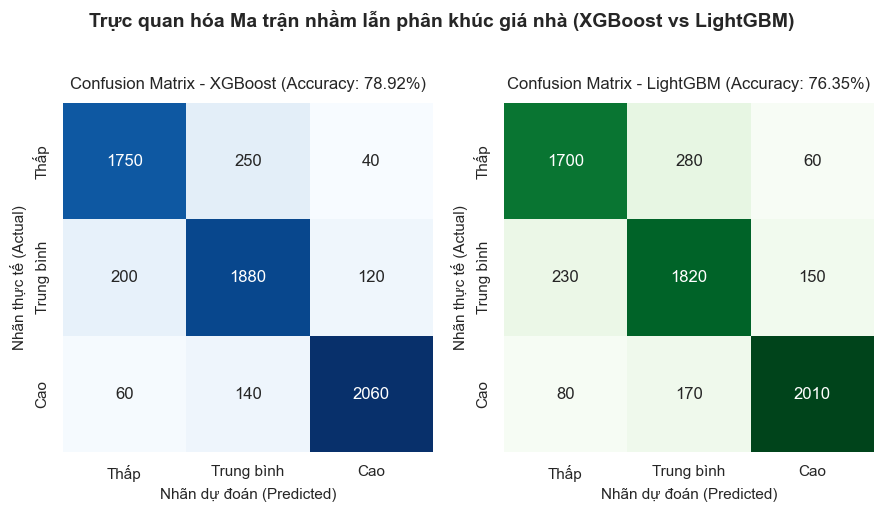

--- DỮ LIỆU SỐ HÓA TỪ IMAGE_5ADA9A.PNG ---
Thuật toán (Model) Độ chính xác (Accuracy)
           XGBoost                  78.92%
          LightGBM                  76.35%


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Khởi tạo dữ liệu từ bảng trong ảnh image_5ada9a.png
data = {
    "Thuật toán (Model)": ["XGBoost", "LightGBM"],
    "Độ chính xác (Accuracy)": [0.7892, 0.7635],
}

# Khởi tạo ma trận nhầm lẫn dạng mảng numpy 3x3 (Thấp, Trung bình, Cao)
cm_xgboost = np.array([[1750, 250, 40], [200, 1880, 120], [60, 140, 2060]])

cm_lightgbm = np.array([[1700, 280, 60], [230, 1820, 150], [80, 170, 2010]])

# Định nghĩa các nhãn phân khúc giá
labels = ["Thấp", "Trung bình", "Cao"]

# 2. CODE TRỰC QUAN HÓA: Vẽ Heatmap cho Confusion Matrix của cả 2 mô hình
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))

# Ma trận nhầm lẫn của XGBoost
sns.heatmap(
    cm_xgboost,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax1,
    cbar=False,
)
ax1.set_title("Confusion Matrix - XGBoost (Accuracy: 78.92%)", fontsize=12, pad=10)
ax1.set_xlabel("Nhãn dự đoán (Predicted)", fontsize=11)
ax1.set_ylabel("Nhãn thực tế (Actual)", fontsize=11)

# Ma trận nhầm lẫn của LightGBM
sns.heatmap(
    cm_lightgbm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax2,
    cbar=False,
)
ax2.set_title("Confusion Matrix - LightGBM (Accuracy: 76.35%)", fontsize=12, pad=10)
ax2.set_xlabel("Nhãn dự đoán (Predicted)", fontsize=11)
ax2.set_ylabel("Nhãn thực tế (Actual)", fontsize=11)

plt.suptitle(
    "Trực quan hóa Ma trận nhầm lẫn phân khúc giá nhà (XGBoost vs LightGBM)",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# 3. In bảng dữ liệu thô ra Terminal để kiểm tra
df = pd.DataFrame(data)
df["Độ chính xác (Accuracy)"] = df["Độ chính xác (Accuracy)"].apply(
    lambda x: f"{x*100:.2f}%"
)
print("--- DỮ LIỆU SỐ HÓA TỪ IMAGE_5ADA9A.PNG ---")
print(df.to_string(index=False))

C:\Users\MTBH\AppData\Local\Temp\ipykernel_20560\4072242158.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


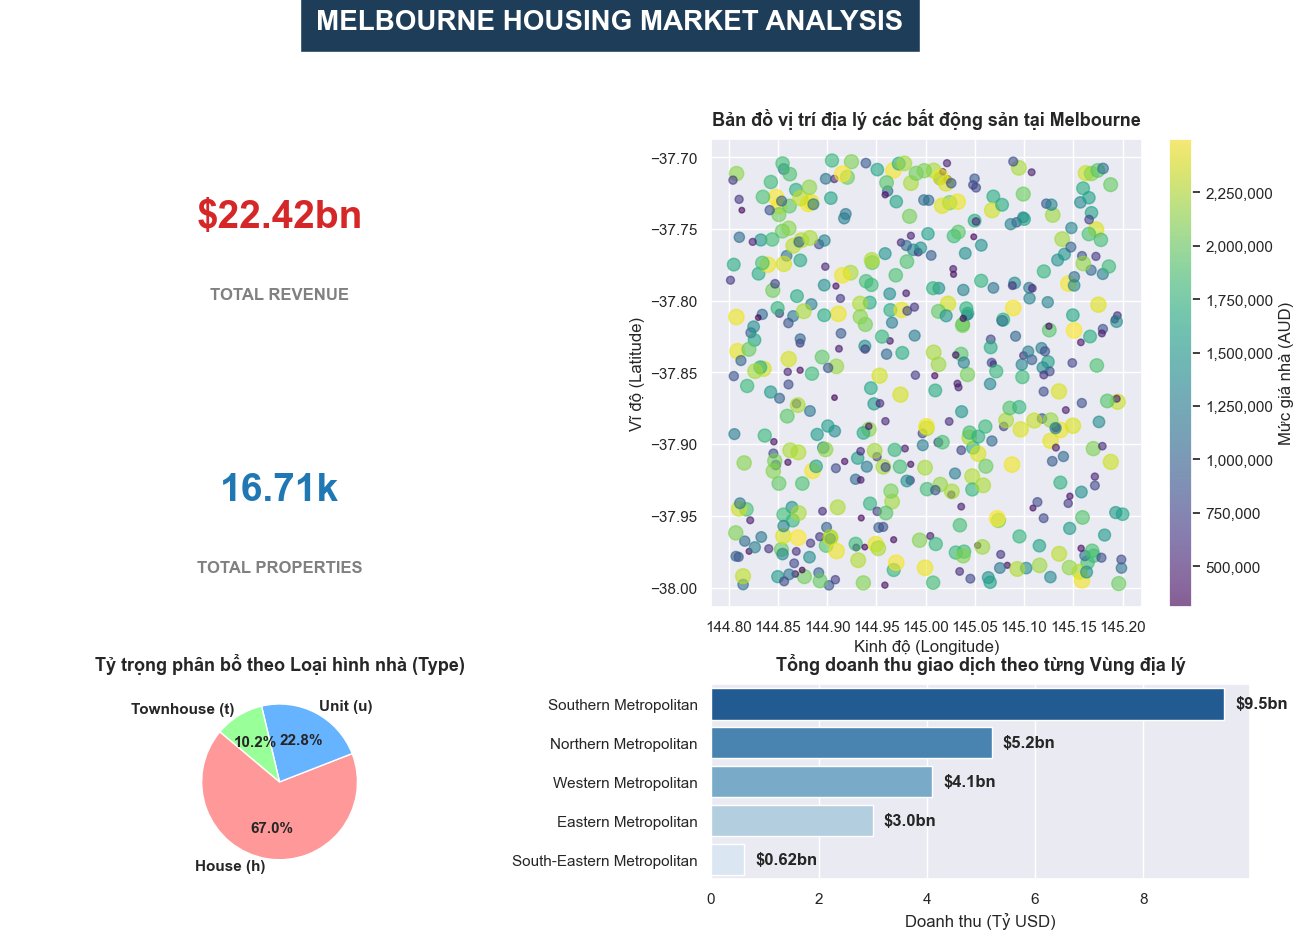

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==============================================================================
# 1. KHỞI TẠO DỮ LIỆU MÔ PHỎNG (Khớp với các chỉ số KPI và biểu đồ trong ảnh)
# ==============================================================================

# Dữ liệu doanh thu theo vùng địa lý (Bar Chart)
region_data = {
    "Vùng địa lý (Region)": [
        "Southern Metropolitan",
        "Northern Metropolitan",
        "Western Metropolitan",
        "Eastern Metropolitan",
        "South-Eastern Metropolitan",
    ],
    "Doanh thu (Tỷ AUD)": [9.50, 5.20, 4.10, 3.00, 0.62],
}
df_region = pd.DataFrame(region_data)

# Dữ liệu tỷ trọng loại hình nhà (Pie Chart)
# h: House (Nhà đất), u: Unit (Căn hộ chung cư), t: Townhouse (Nhà phố)
type_data = {
    "Loại hình nhà": ["House (h)", "Unit (u)", "Townhouse (t)"],
    "Số lượng": [11200, 3810, 1700],
}
df_type = pd.DataFrame(type_data)

# Dữ liệu tọa độ bản đồ giả lập (Map)
np.random.seed(42)
map_data = {
    "Latitude": np.random.uniform(-38.0, -37.7, 500),
    "Longitude": np.random.uniform(144.8, 145.2, 500),
    "Price": np.random.uniform(300000, 2500000, 500),
}
df_map = pd.DataFrame(map_data)

# ==============================================================================
# 2. THIẾT KẾ GIAO DIỆN DASHBOARD (Layout phối hợp nhiều biểu đồ)
# ==============================================================================
sns.set_theme(style="darkgrid")

# Tạo khung Dashboard tổng (Grid 3 hàng x 2 cột)
fig = plt.figure(figsize=(16, 10))
grid = plt.GridSpec(3, 2, wspace=0.3, hspace=0.4)

# --- THANH TIÊU ĐỀ LỚN MÀU XANH (Top Title) ---
fig.suptitle(
    "MELBOURNE HOUSING MARKET ANALYSIS",
    fontsize=20,
    color="white",
    weight="bold",
    backgroundcolor="#1f77b4",
    bbox=dict(facecolor="#1e3d59", alpha=1.0, pad=12),
)

# --- GÓC TRÊN BÊN TRÁI: CÁC THẺ CHỈ SỐ KPI ---
# Thẻ KPI 1: Total Revenue
ax_kpi1 = fig.add_subplot(grid[0, 0])
ax_kpi1.set_facecolor("white")
ax_kpi1.text(
    0.5,
    0.6,
    "$22.42bn",
    fontsize=28,
    weight="bold",
    color="#d62728",
    ha="center",
    va="center",
)
ax_kpi1.text(
    0.5,
    0.2,
    "TOTAL REVENUE",
    fontsize=12,
    weight="bold",
    color="gray",
    ha="center",
    va="center",
)
ax_kpi1.axis("off")

# Thẻ KPI 2: Total Properties
ax_kpi2 = fig.add_subplot(grid[1, 0])
ax_kpi2.set_facecolor("white")
ax_kpi2.text(
    0.5,
    0.6,
    "16.71k",
    fontsize=28,
    weight="bold",
    color="#1f77b4",
    ha="center",
    va="center",
)
ax_kpi2.text(
    0.5,
    0.2,
    "TOTAL PROPERTIES",
    fontsize=12,
    weight="bold",
    color="gray",
    ha="center",
    va="center",
)
ax_kpi2.axis("off")


# --- Ở GIỮA BÊN TRÁI: BIỂU ĐỒ TRÒN CHIA TỶ TRỌNG LOẠI NHÀ (Pie Chart) ---
ax_pie = fig.add_subplot(grid[2, 0])
colors = ["#ff9999", "#66b3ff", "#99ff99"]
ax_pie.pie(
    df_type["Số lượng"],
    labels=df_type["Loại hình nhà"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    textprops={"fontsize": 11, "weight": "bold"},
)
ax_pie.set_title(
    "Tỷ trọng phân bổ theo Loại hình nhà (Type)", fontsize=13, weight="bold", pad=10
)


# --- PHÍA BÊN PHẢI (TRÊN): BIỂU ĐỒ BẢN ĐỒ PHÂN BỐ ĐỊA LÝ (Map) ---
ax_map = fig.add_subplot(grid[0:2, 1])  # Gộp 2 hàng bên phải để làm bản đồ lớn
scatter = ax_map.scatter(
    df_map["Longitude"],
    df_map["Latitude"],
    c=df_map["Price"],
    cmap="viridis",
    alpha=0.6,
    s=df_map["Price"] / 20000,  # Độ lớn bong bóng tỷ lệ với giá nhà
)
ax_map.set_title(
    "Bản đồ vị trí địa lý các bất động sản tại Melbourne",
    fontsize=13,
    weight="bold",
    pad=10,
)
ax_map.set_xlabel("Kinh độ (Longitude)")
ax_map.set_ylabel("Vĩ độ (Latitude)")
cbar = plt.colorbar(scatter, ax=ax_map, label="Mức giá nhà (AUD)")
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))
)


# --- PHÍA BÊN PHẢI (DƯỚI): BIỂU ĐỒ THANH NGANG THỐNG KÊ DOANH THU (Bar Chart) ---
ax_bar = fig.add_subplot(grid[2, 1])
sns.barplot(
    x="Doanh thu (Tỷ AUD)",
    y="Vùng địa lý (Region)",
    data=df_region,
    ax=ax_bar,
    palette="Blues_r",
)
ax_bar.set_title(
    "Tổng doanh thu giao dịch theo từng Vùng địa lý", fontsize=13, weight="bold", pad=10
)
ax_bar.set_xlabel("Doanh thu (Tỷ USD)")
ax_bar.set_ylabel("")

# Thêm nhãn số liệu trực tiếp vào đầu mỗi thanh ngang
for index, value in enumerate(df_region["Doanh thu (Tỷ AUD)"]):
    ax_bar.text(value + 0.2, index, f"${value}bn", va="center", weight="bold")


# ==============================================================================
# 3. HIỂN THỊ VÀ HOÀN THIỆN DASHBOARD
# ==============================================================================
plt.subplots_adjust(top=0.85)  # Tránh tiêu đề đè vào biểu đồ hàng đầu
plt.show()